In [1]:
import pandas as pd
import polars as pl
import numpy as np
from collections import defaultdict
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

## Load All-vs-All Foldseek Results

Load the foldseek search results and metadata with species information.

In [21]:
# Load foldseek all-vs-all results using Polars for speed
# Expected format: query, target, qstart, qend, tstart, tend, evalue, bits, etc.
foldseek_results = pl.read_csv(
    'flavi_allvall.tsv', 
    separator='\t', 
    has_header=False
)

# Standard foldseek output columns
columns = ['query', 'target', 'fident', 'alnlen', 'mismatch', 'gapopen', 
           'qstart', 'qend', 'tstart', 'tend', 'evalue', 'bits']
foldseek_results.columns = columns[:foldseek_results.width]

print(f"Loaded {len(foldseek_results)} alignments")
print(f"Unique sequences: {foldseek_results['query'].n_unique()}")
foldseek_results.head()

Loaded 315501 alignments
Unique sequences: 621


query,target,fident,alnlen,mismatch,gapopen,qstart,qend,tstart,tend,evalue,bits
str,str,f64,i64,i64,i64,i64,i64,i64,i64,f64,i64
"""PLLG_Fushun_laodelphax_striate…","""PLLG_Fushun_laodelphax_striate…",1.0,3708,0,0,1,3708,1,3708,0.0,25091
"""PLLG_Fushun_laodelphax_striate…","""PLLG_Xiangshan_flavi-like_viru…",0.166,2088,1535,0,1618,3705,88,1928,2.6890e-42,2024
"""PLLG_Fushun_laodelphax_striate…","""PLLG_Plodia_interpunctella_ass…",0.138,3537,2492,0,171,3707,7,2898,3.2720e-40,1927
"""PLLG_Fushun_laodelphax_striate…","""PLLG_Drosophila-associated_fla…",0.117,3964,3106,0,53,3571,2,3965,3.7810e-36,1738
"""PLLG_Fushun_laodelphax_striate…","""PLLG_Locusta_migratoria_associ…",0.121,3619,3083,0,195,3702,73,3691,1.7960e-34,1660


In [3]:
# Load or create metadata with species information using Polars
# Adjust this to match your metadata format
# Example: parsing species from sequence IDs or loading from a separate file

def extract_species_from_id(seq_id):
    """Extract species information from sequence ID"""
    # Customize this function based on your ID format
    # Example: "sp|P12345|PROTEIN_SPECIES" -> "SPECIES"
    parts = seq_id.split('|')
    if len(parts) >= 3:
        return parts[-1].split('_')[-1]
    return seq_id.split('_')[0] if '_' in seq_id else 'unknown'

# Create metadata using Polars
unique_seqs = pl.DataFrame({
    'seq_id': pl.concat([
        foldseek_results.select('query').to_series(),
        foldseek_results.select('target').to_series()
    ]).unique()
})

unique_seqs = unique_seqs.with_columns(
    pl.col('seq_id').map_elements(extract_species_from_id, return_dtype=pl.Utf8).alias('species')
)

print(f"Found {unique_seqs['species'].n_unique()} unique species")
print(unique_seqs.head())

Found 15 unique species
shape: (5, 2)
┌─────────────────────────────────┬─────────┐
│ seq_id                          ┆ species │
│ ---                             ┆ ---     │
│ str                             ┆ str     │
╞═════════════════════════════════╪═════════╡
│ FJAF_Crangon_crangon_flaviviru… ┆ FJAF    │
│ PLLG_Flaviviridae_sp._isolate_… ┆ PLLG    │
│ PLLG_Bole_tick_virus_4_strain_… ┆ PLLG    │
│ HPHV_Hepatitis_C_virus_genotyp… ┆ HPHV    │
│ FJJI_Jingmen_tick_virus_isolat… ┆ FJJI    │
└─────────────────────────────────┴─────────┘


## Analyze Hit Overlaps to Find Consensus Regions

For each query sequence, collect all alignment regions from the all-vs-all search and identify consensus regions based on overlapping hits.

In [24]:
import tqdm

def find_consensus_regions(alignments_df, min_overlap_fraction=0.5, min_species_support=2, jaccard_threshold=0.3):
    """
    Identify consensus regions based on alignment overlaps using Polars for speed.
    
    Parameters:
    - alignments_df: Polars DataFrame with query, target, qstart, qend columns
    - min_overlap_fraction: Minimum fraction of sequences that must overlap a region
    - min_species_support: Minimum number of different species supporting a region
    - jaccard_threshold: Minimum Jaccard similarity between adjacent positions to be continuous
    
    Returns:
    - Dictionary mapping query sequences to list of consensus regions
    """
    consensus_regions = {}
    
    # Group by query sequence
    unique_queries = alignments_df.select('query').unique().to_series().to_list()
    
    for query_seq in tqdm.tqdm(unique_queries):
        query_alns = alignments_df.filter(pl.col('query') == query_seq)
        
        if len(query_alns) == 0:
            continue
        
        # Collect all alignment intervals efficiently
        intervals = query_alns.select([
            pl.col('qstart').alias('start'),
            pl.col('qend').alias('end'),
            pl.col('target'),
            pl.when(pl.col('evalue').is_not_null())
              .then(pl.col('evalue'))
              .otherwise(pl.lit(1.0))
              .alias('evalue')
        ]).to_dicts()
        
        # Find regions with high overlap using Jaccard similarity
        regions = cluster_by_jaccard_similarity(
            intervals, 
            min_overlap_fraction=min_overlap_fraction,
            min_species_support=min_species_support,
            jaccard_threshold=jaccard_threshold,
            metadata=unique_seqs
        )
        
        consensus_regions[query_seq] = regions
    
    return consensus_regions


def jaccard_similarity(set1, set2):
    """Calculate Jaccard similarity between two sets."""
    if len(set1) == 0 and len(set2) == 0:
        return 1.0
    intersection = len(set1 & set2)
    union = len(set1 | set2)
    return intersection / union if union > 0 else 0.0


def cluster_by_jaccard_similarity(intervals, min_overlap_fraction, min_species_support, jaccard_threshold, metadata , no_merge_regions=False):
    """
    Cluster intervals based on species composition similarity using Jaccard index.
    
    Uses species sets at each position and Jaccard similarity between adjacent
    positions to determine region boundaries.
    """
    if not intervals:
        return []
    
    # Sort intervals by start position
    intervals = sorted(intervals, key=lambda x: x['start'])
    
    # Get min and max positions
    min_pos = min(i['start'] for i in intervals)
    max_pos = max(i['end'] for i in intervals)
    
    # Precompute species mapping for faster lookups
    species_map = {
        row['seq_id']: row['species'] 
        for row in metadata.select(['seq_id', 'species']).to_dicts()
    }
    
    # Build species sets for each position
    position_species = {}
    position_coverage = {}
    
    for interval in intervals:
        species = species_map.get(interval['target'], 'unknown')
        for pos in range(interval['start'], interval['end'] + 1):
            if pos not in position_species:
                position_species[pos] = set()
                position_coverage[pos] = 0
            position_species[pos].add(species)
            position_coverage[pos] += 1
    
    # Filter positions by coverage and species support
    total_seqs = len(set(i['target'] for i in intervals))
    min_coverage = max(min_species_support, int(total_seqs * min_overlap_fraction))
    
    valid_positions = [
        pos for pos in sorted(position_species.keys())
        if position_coverage[pos] >= min_coverage 
        and len(position_species[pos]) >= min_species_support
    ]
    
    if not valid_positions:
        return []
    
    # Cluster positions based on Jaccard similarity between adjacent sites
    regions = []
    current_region_start = valid_positions[0]
    current_region_positions = [valid_positions[0]]
    
    for i in range(1, len(valid_positions)):
        prev_pos = valid_positions[i-1]
        curr_pos = valid_positions[i]
        
        # Calculate Jaccard similarity between adjacent valid positions
        prev_species = position_species[prev_pos]
        curr_species = position_species[curr_pos]
        similarity = jaccard_similarity(prev_species, curr_species)
        
        # Check if positions are continuous (adjacent or similar species composition)
        is_adjacent = (curr_pos - prev_pos) <= 1
        is_similar = similarity >= jaccard_threshold
        
        if is_adjacent and is_similar:
            # Continue current region
            current_region_positions.append(curr_pos)
        else:
            # End current region and start new one
            if current_region_positions:
                region_start = current_region_positions[0]
                region_end = current_region_positions[-1]
                
                # Calculate region statistics
                region_coverages = [position_coverage[p] for p in current_region_positions]
                region_species = set()
                for p in current_region_positions:
                    region_species.update(position_species[p])
                
                regions.append({
                    'start': region_start,
                    'end': region_end,
                    'max_coverage': int(max(region_coverages)),
                    'avg_coverage': float(np.mean(region_coverages)),
                    'species_count': len(region_species),
                    'avg_jaccard': similarity  # Store last similarity for reference
                })
            
            # Start new region
            current_region_start = curr_pos
            current_region_positions = [curr_pos]
    
    # Add final region
    if current_region_positions:
        region_start = current_region_positions[0]
        region_end = current_region_positions[-1]
        
        region_coverages = [position_coverage[p] for p in current_region_positions]
        region_species = set()
        for p in current_region_positions:
            region_species.update(position_species[p])
        
        regions.append({
            'start': region_start,
            'end': region_end,
            'max_coverage': int(max(region_coverages)),
            'avg_coverage': float(np.mean(region_coverages)),
            'species_count': len(region_species),
            'avg_jaccard': 1.0  # Last region
        })
    if no_merge_regions:
        return regions
    
    # Optional: merge very close regions with high Jaccard similarity
    merged_regions = []
    for region in regions:
        if not merged_regions:
            merged_regions.append(region)
        else:
            last_region = merged_regions[-1]
            gap = region['start'] - last_region['end']
            
            # Check Jaccard between end of last region and start of current
            if gap <= 10:
                last_species = set()
                for p in range(max(min_pos, last_region['end'] - 5), last_region['end'] + 1):
                    if p in position_species:
                        last_species.update(position_species[p])
                
                curr_species = set()
                for p in range(region['start'], min(region['start'] + 5, max_pos + 1)):
                    if p in position_species:
                        curr_species.update(position_species[p])
                
                merge_similarity = jaccard_similarity(last_species, curr_species)
                
                if merge_similarity >= jaccard_threshold:
                    # Merge regions
                    all_species = set()
                    for p in range(last_region['start'], region['end'] + 1):
                        if p in position_species:
                            all_species.update(position_species[p])
                    
                    merged_regions[-1]['end'] = region['end']
                    merged_regions[-1]['max_coverage'] = max(last_region['max_coverage'], region['max_coverage'])
                    merged_regions[-1]['avg_coverage'] = (last_region['avg_coverage'] + region['avg_coverage']) / 2
                    merged_regions[-1]['species_count'] = len(all_species)
                    continue
            
            merged_regions.append(region)
    
    return merged_regions


In [25]:
# Run consensus region identification with Jaccard similarity-based clustering
print("Identifying consensus regions using Jaccard similarity...")
consensus_regions = find_consensus_regions(
    foldseek_results,
    min_overlap_fraction=0.1,  # At least 10% of sequences must overlap
    min_species_support=2,      # At least 20 different species
    jaccard_threshold=0.95       # Minimum Jaccard similarity for continuity
)

# Display summary
print(f"\nFound consensus regions for {len(consensus_regions)} sequences")
for seq_id, regions in list(consensus_regions.items())[:5]:  # Show first 5
    print(f"\n{seq_id}: {len(regions)} regions")
    for i, region in enumerate(regions, 1):
        print(f"  Region {i}: {region['start']}-{region['end']} "
              f"(length: {region['end']-region['start']+1}, "
              f"coverage: {region['avg_coverage']:.1f}, "
              f"species: {region['species_count']})")

Identifying consensus regions using Jaccard similarity...


100%|██████████| 621/621 [02:47<00:00,  3.71it/s]


Found consensus regions for 621 sequences

TOMB_Red_clover_necrotic_mosaic_virus_segment_2_orfmovement: 11 regions
  Region 1: 1-11 (length: 11, coverage: 76.3, species: 12)
  Region 2: 12-42 (length: 31, coverage: 119.6, species: 13)
  Region 3: 43-69 (length: 27, coverage: 217.9, species: 14)
  Region 4: 70-222 (length: 153, coverage: 193.5, species: 15)
  Region 5: 223-244 (length: 22, coverage: 103.2, species: 14)
  Region 6: 245-269 (length: 25, coverage: 76.4, species: 13)
  Region 7: 270-285 (length: 16, coverage: 55.2, species: 12)
  Region 8: 286-306 (length: 21, coverage: 48.0, species: 11)
  Region 9: 307-310 (length: 4, coverage: 40.0, species: 10)
  Region 10: 311-312 (length: 2, coverage: 36.0, species: 9)
  Region 11: 313-315 (length: 3, coverage: 26.7, species: 8)

HPHV_Hepacivirus_F_isolate_MgHV4: 17 regions
  Region 1: 1-4 (length: 4, coverage: 90.8, species: 5)
  Region 2: 5-7 (length: 3, coverage: 121.3, species: 6)
  Region 3: 8-33 (length: 26, coverage: 148.9, sp

In [26]:
#filter consensus regions to only those with at least 20 amino acids
for seq_id in consensus_regions:
    consensus_regions[seq_id] = [
		region for region in consensus_regions[seq_id]
		if (region['end'] - region['start'] + 1) >= 40
	]

## Visualize Coverage and Consensus Regions

Create visualizations showing alignment coverage across sequences and identified consensus regions.

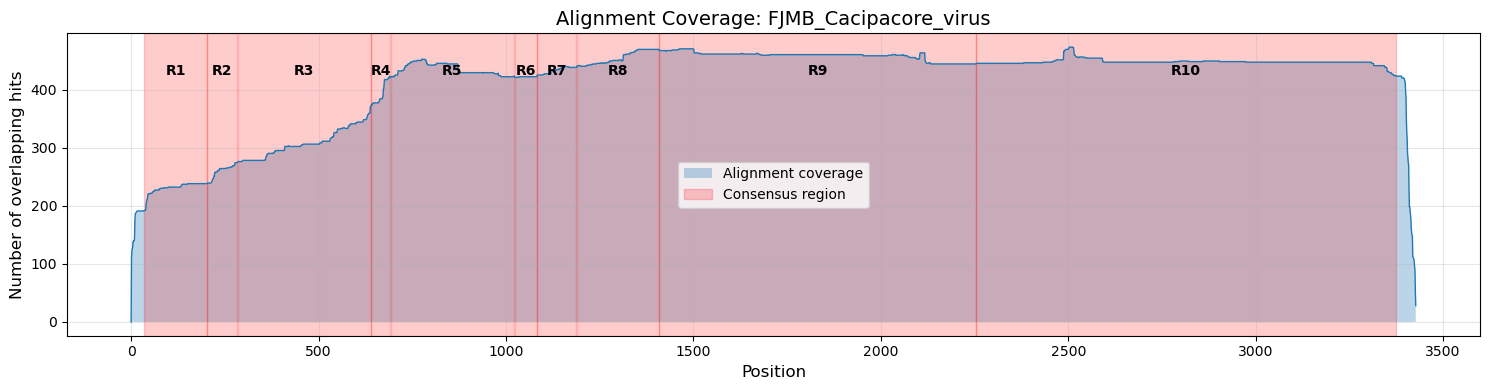

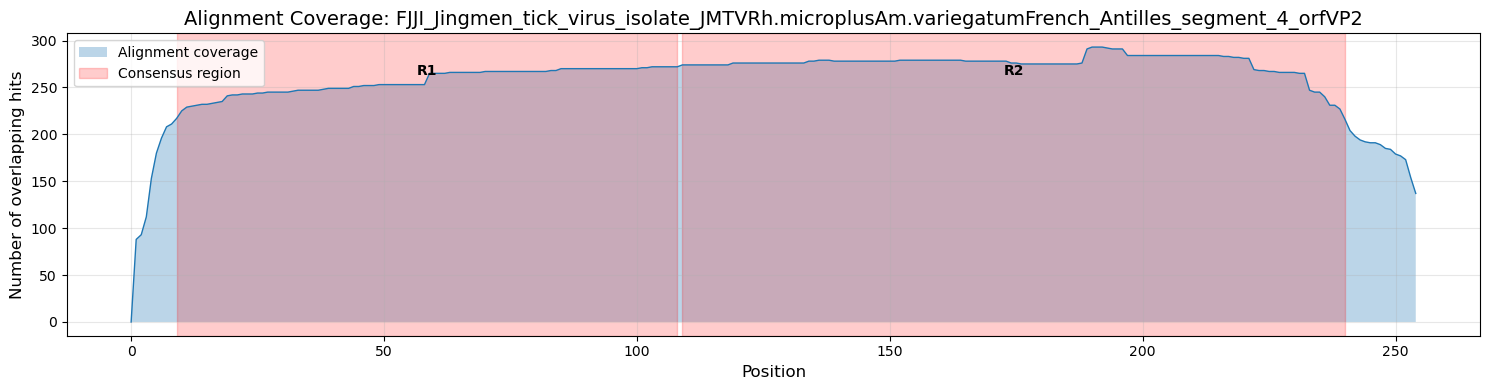

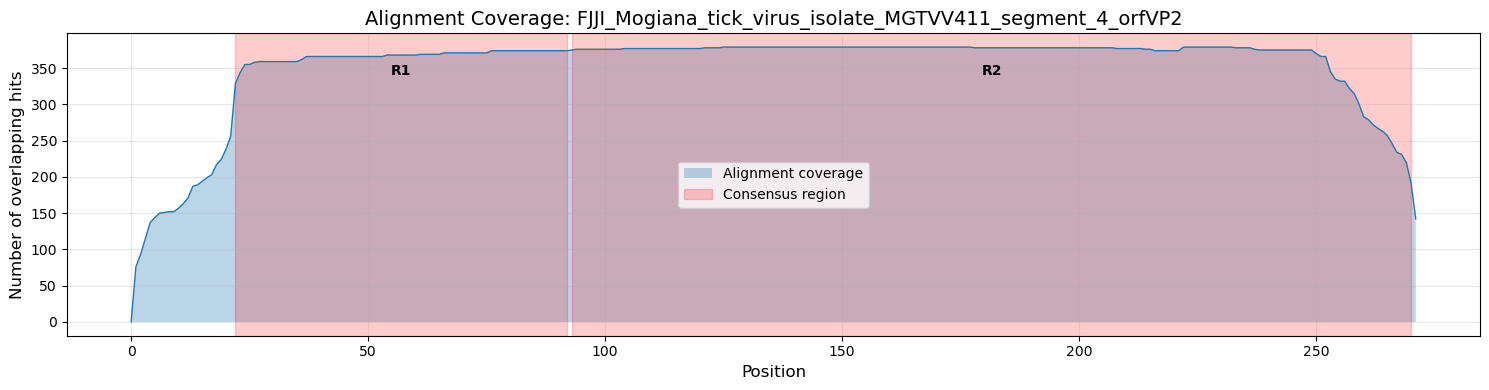

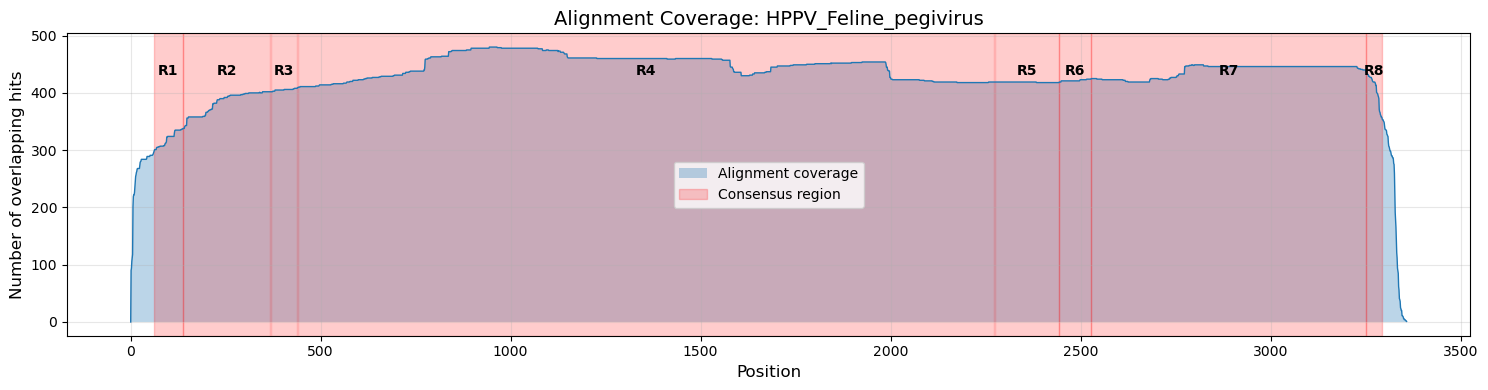

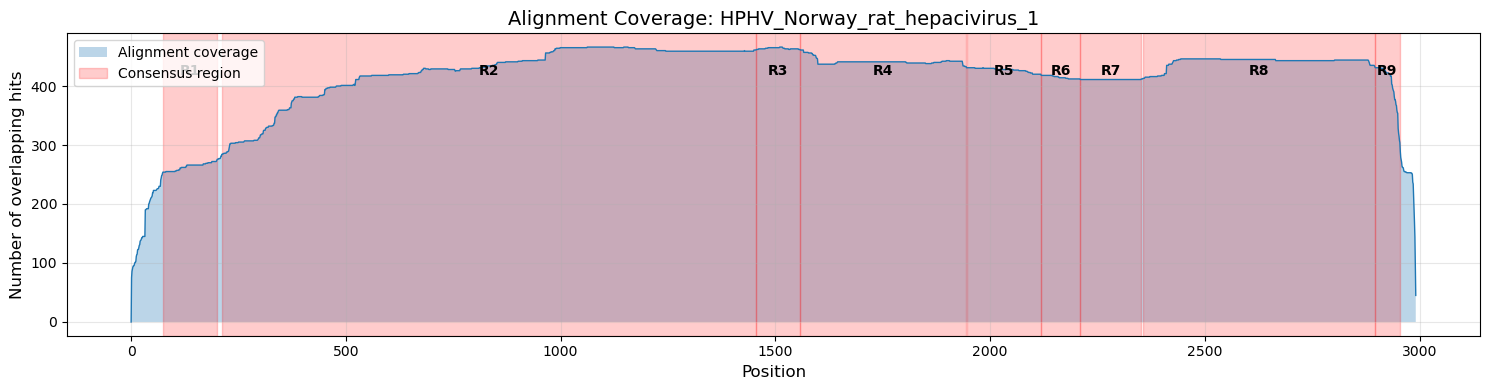

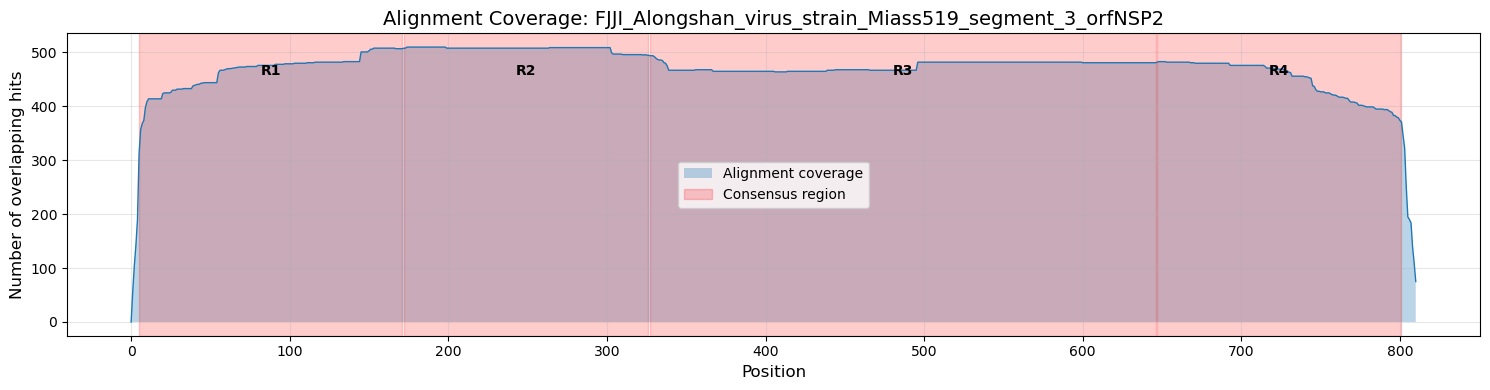

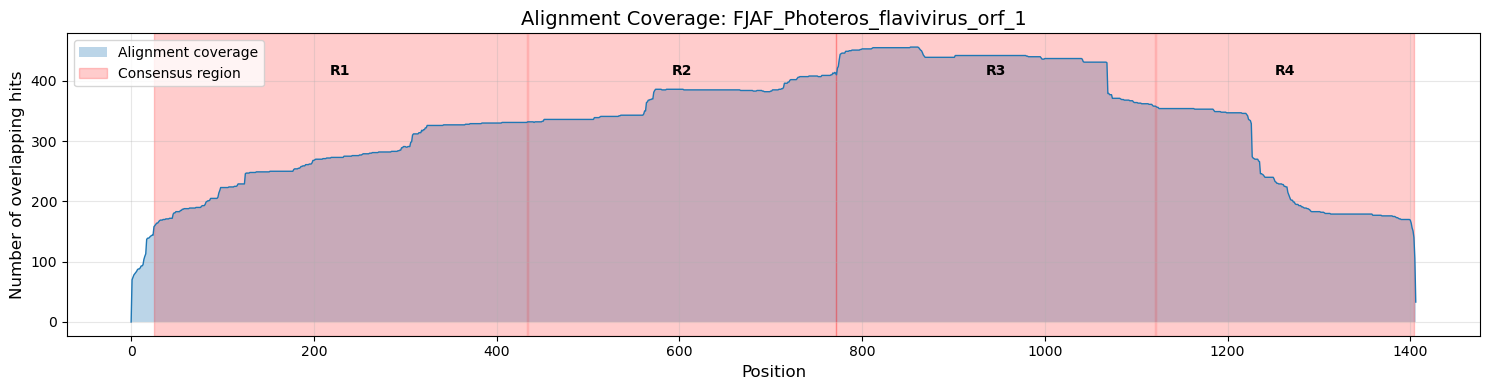

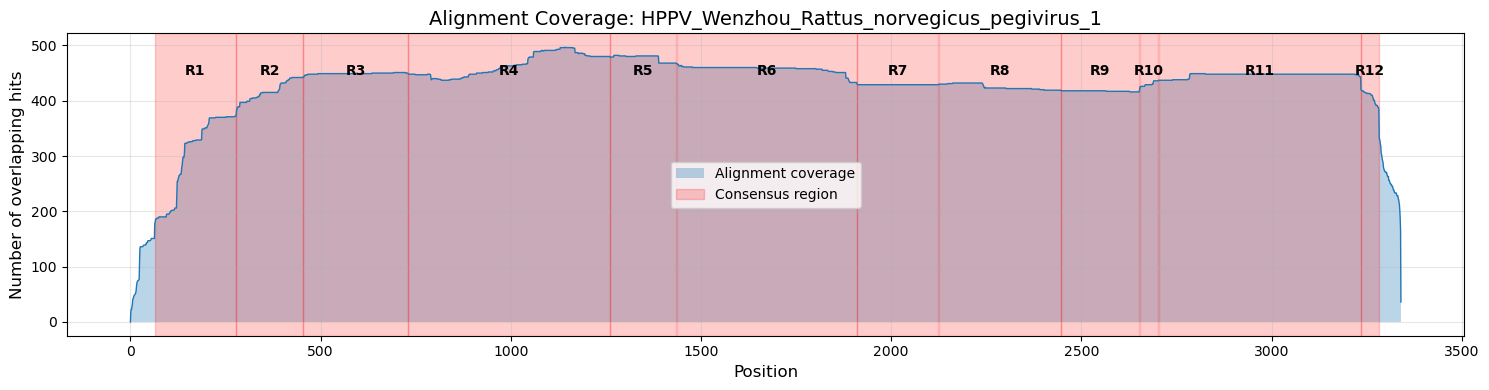

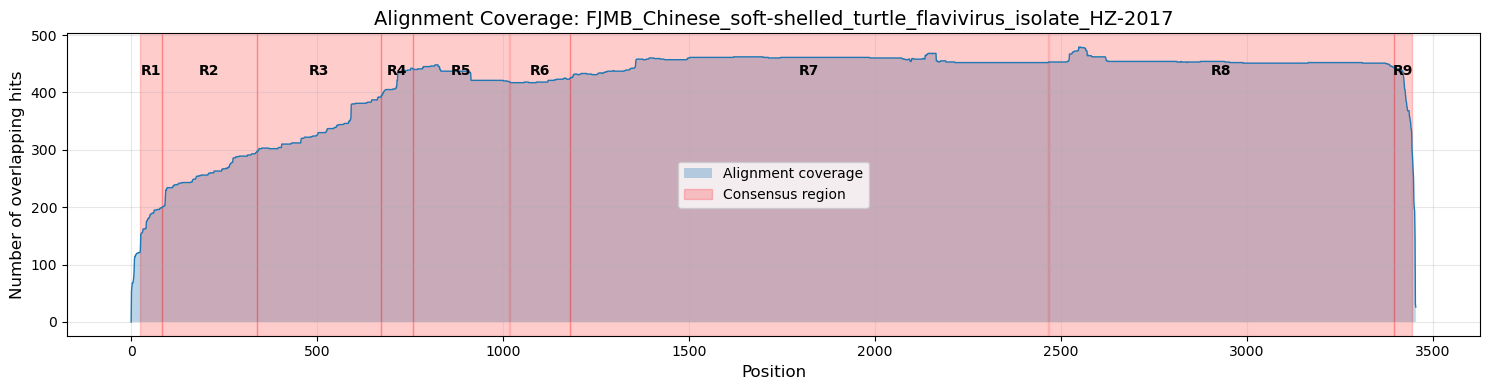

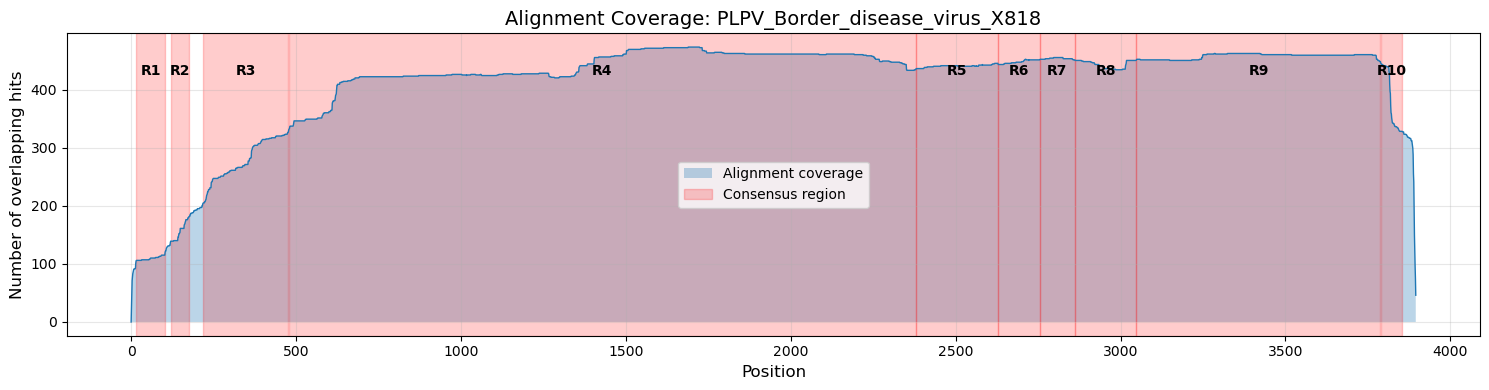

In [17]:
def plot_sequence_coverage(query_seq, alignments_df, consensus_regions, max_pos=None):
    """
    Plot alignment coverage for a specific sequence with consensus regions highlighted.
    Works with Polars DataFrame.
    """
    query_alns = alignments_df.filter(pl.col('query') == query_seq)
    
    if len(query_alns) == 0:
        print(f"No alignments found for {query_seq}")
        return
    
    # Determine sequence length
    if max_pos is None:
        max_pos = query_alns.select(pl.col('qend').max()).item()
    
    # Calculate coverage at each position using numpy for speed
    coverage = np.zeros(max_pos + 1)
    for row in query_alns.select(['qstart', 'qend']).to_dicts():
        coverage[row['qstart']:row['qend']+1] += 1
    
    # Plot
    fig, ax = plt.subplots(figsize=(15, 4))
    
    # Plot coverage
    positions = np.arange(len(coverage))
    ax.fill_between(positions, coverage, alpha=0.3, label='Alignment coverage')
    ax.plot(positions, coverage, linewidth=1)
    
    # Highlight consensus regions
    regions = consensus_regions.get(query_seq, [])
    for i, region in enumerate(regions):
        ax.axvspan(region['start'], region['end'], alpha=0.2, color='red', 
                   label='Consensus region' if i == 0 else '')
        ax.text((region['start'] + region['end']) / 2, coverage.max() * 0.9,
                f"R{i+1}", ha='center', fontsize=10, weight='bold')
    
    ax.set_xlabel('Position', fontsize=12)
    ax.set_ylabel('Number of overlapping hits', fontsize=12)
    ax.set_title(f'Alignment Coverage: {query_seq}', fontsize=14)
    ax.legend()
    ax.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    return fig
#select 3 random keys

import random

for i in range( 10 ):
# Plot coverage for first sequence with regions
	first_seq = random.choice(list(consensus_regions.keys()))
	plot_sequence_coverage(first_seq, foldseek_results, consensus_regions)

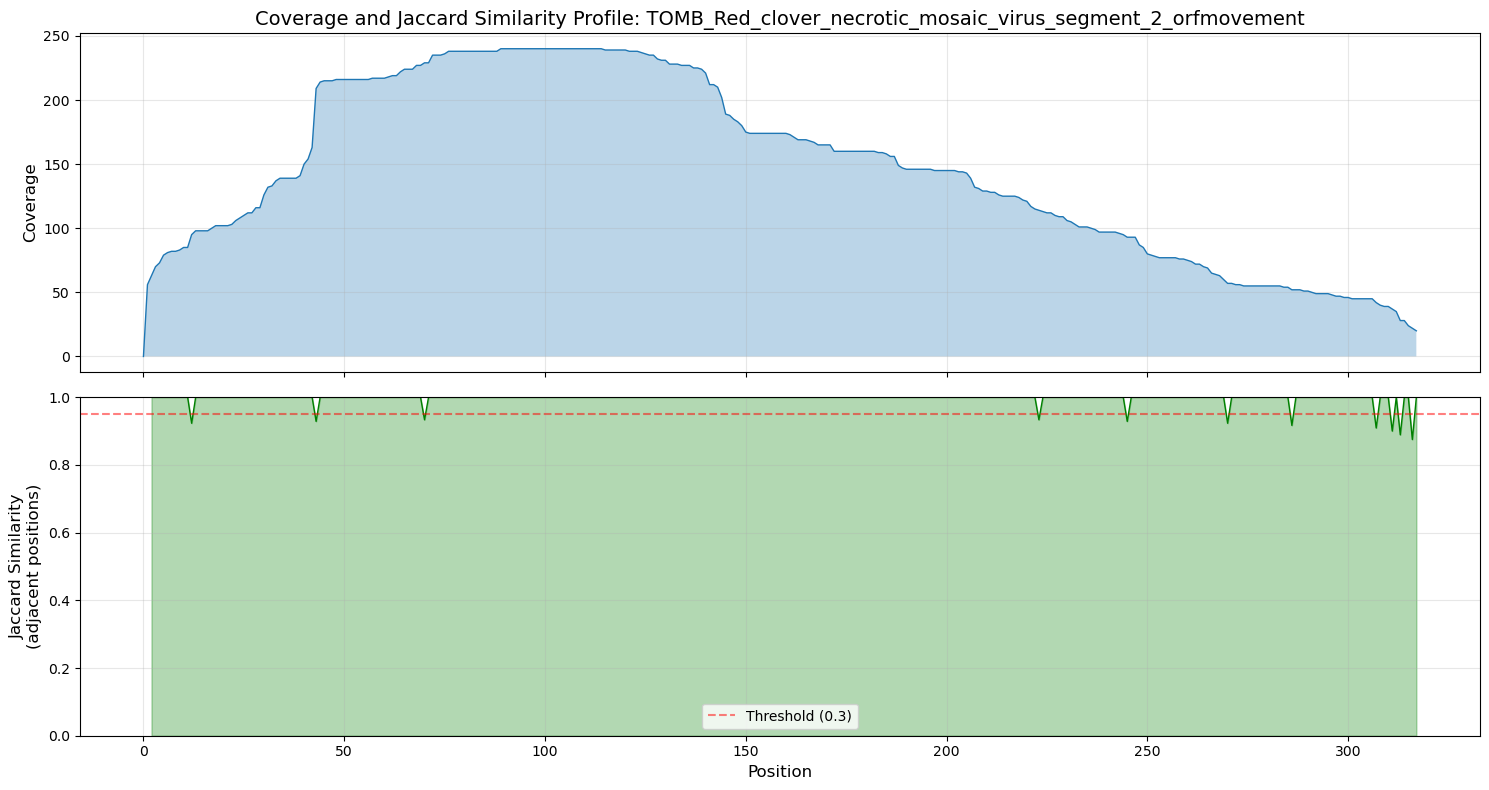

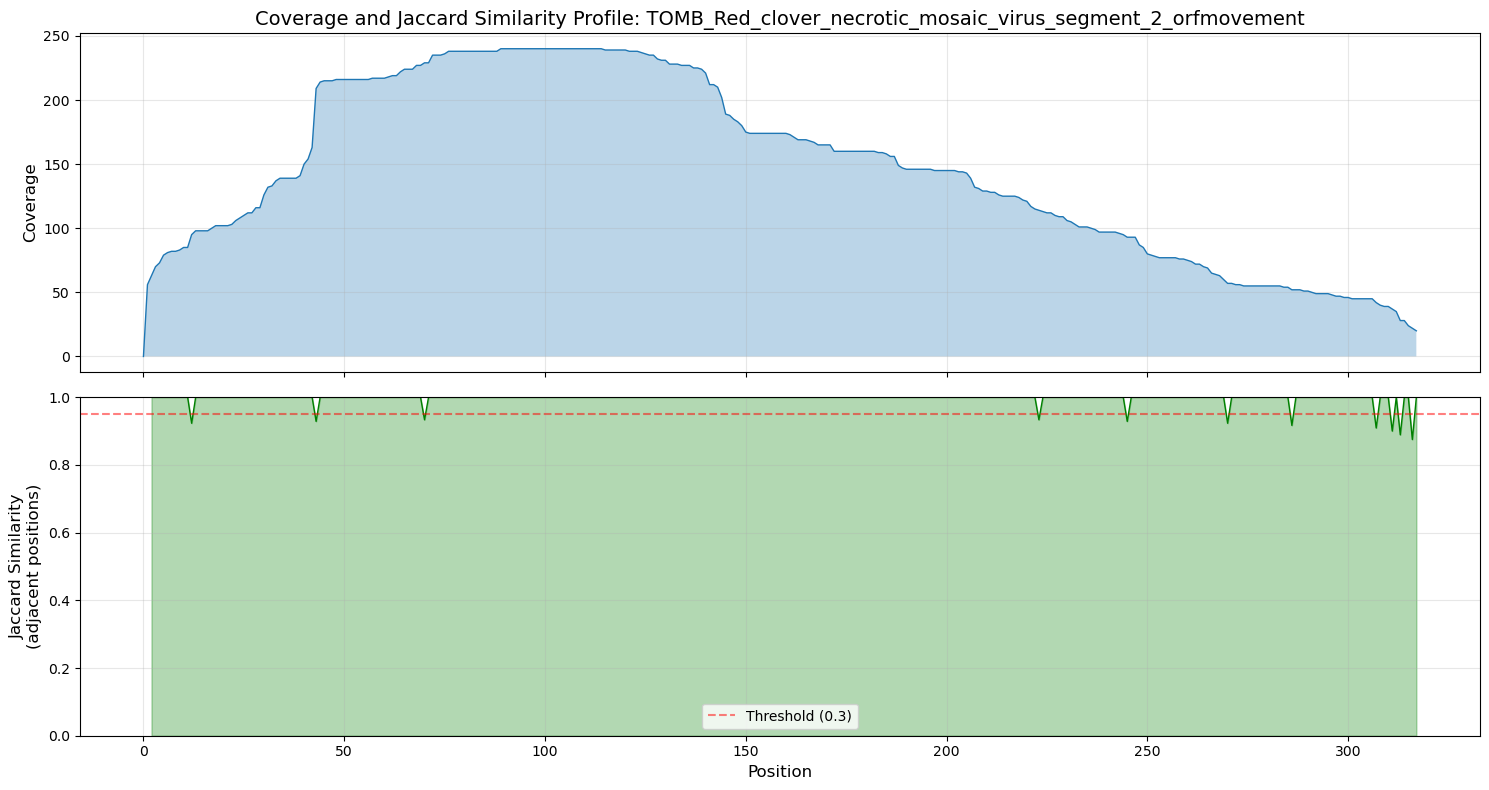

In [27]:
def plot_jaccard_profile(query_seq, alignments_df, metadata, max_pos=None):
    """
    Plot Jaccard similarity profile showing how species composition changes along a sequence.
    """
    query_alns = alignments_df.filter(pl.col('query') == query_seq)
    
    if len(query_alns) == 0:
        print(f"No alignments found for {query_seq}")
        return
    
    # Determine sequence length
    if max_pos is None:
        max_pos = query_alns.select(pl.col('qend').max()).item()
    
    # Precompute species mapping
    species_map = {
        row['seq_id']: row['species'] 
        for row in metadata.select(['seq_id', 'species']).to_dicts()
    }
    
    # Build species sets for each position
    position_species = {}
    intervals = query_alns.select(['qstart', 'qend', 'target']).to_dicts()
    
    for interval in intervals:
        species = species_map.get(interval['target'], 'unknown')
        for pos in range(interval['qstart'], interval['qend'] + 1):
            if pos not in position_species:
                position_species[pos] = set()
            position_species[pos].add(species)
    
    # Calculate Jaccard similarities between adjacent positions
    positions = sorted(position_species.keys())
    jaccard_scores = []
    jaccard_positions = []
    
    for i in range(1, len(positions)):
        prev_pos = positions[i-1]
        curr_pos = positions[i]
        
        if curr_pos - prev_pos <= 5:  # Only calculate for nearby positions
            prev_species = position_species[prev_pos]
            curr_species = position_species[curr_pos]
            
            intersection = len(prev_species & curr_species)
            union = len(prev_species | curr_species)
            jaccard = intersection / union if union > 0 else 0.0
            
            jaccard_scores.append(jaccard)
            jaccard_positions.append(curr_pos)
    
    # Plot
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 8), sharex=True)
    
    # Plot 1: Coverage
    coverage = np.zeros(max_pos + 1)
    for row in query_alns.select(['qstart', 'qend']).to_dicts():
        coverage[row['qstart']:row['qend']+1] += 1
    
    ax1.fill_between(np.arange(len(coverage)), coverage, alpha=0.3)
    ax1.plot(coverage, linewidth=1)
    ax1.set_ylabel('Coverage', fontsize=12)
    ax1.grid(alpha=0.3)
    ax1.set_title(f'Coverage and Jaccard Similarity Profile: {query_seq}', fontsize=14)
    
    # Plot 2: Jaccard similarity
    ax2.plot(jaccard_positions, jaccard_scores, linewidth=1, color='green')
    ax2.axhline(y=.95, color='red', linestyle='--', alpha=0.5, label='Threshold (0.3)')
    ax2.fill_between(jaccard_positions, jaccard_scores, alpha=0.3, color='green')
    ax2.set_xlabel('Position', fontsize=12)
    ax2.set_ylabel('Jaccard Similarity\n(adjacent positions)', fontsize=12)
    ax2.set_ylim([0, 1])
    ax2.grid(alpha=0.3)
    ax2.legend()
    
    plt.tight_layout()
    plt.show()
    
    return fig

# Plot Jaccard profile for first sequence
first_seq = list(consensus_regions.keys())[0]
plot_jaccard_profile(first_seq, foldseek_results, unique_seqs)

## Export Consensus Regions

Save the identified consensus regions to files for downstream analysis.

In [28]:
# Convert consensus regions to DataFrame
regions_list = []
for seq_id, regions in consensus_regions.items():
    for i, region in enumerate(regions, 1):
        regions_list.append({
            'sequence_id': seq_id,
            'region_number': i,
            'start': region['start'],
            'end': region['end'],
            'length': region['end'] - region['start'] + 1,
            'avg_coverage': region['avg_coverage'],
            'max_coverage': region['max_coverage'],
            'species_support': region['species_count']
        })

regions_df = pd.DataFrame(regions_list)

# Save to file
output_file = 'consensus_regions.tsv'
regions_df.to_csv(output_file, sep='\t', index=False)
print(f"Saved {len(regions_df)} consensus regions to {output_file}")

# Display summary statistics
print("\nSummary Statistics:")
print(f"Total sequences with regions: {regions_df['sequence_id'].nunique()}")
print(f"Total regions identified: {len(regions_df)}")
print(f"Average region length: {regions_df['length'].mean():.1f} ± {regions_df['length'].std():.1f}")
print(f"Average coverage per region: {regions_df['avg_coverage'].mean():.1f}")

regions_df.head(10)

Saved 4398 consensus regions to consensus_regions.tsv

Summary Statistics:
Total sequences with regions: 618
Total regions identified: 4398
Average region length: 366.0 ± 398.5
Average coverage per region: 350.6


,sequence_id,region_number,start,end,length,avg_coverage,max_coverage,species_support
0,TOMB_Red_clover_necrotic_mosaic_virus_segment_...,1,70,222,153,193.516340,240,15
1,HPHV_Hepacivirus_F_isolate_MgHV4,1,65,1340,1276,410.629310,469,14
2,HPHV_Hepacivirus_F_isolate_MgHV4,2,1341,1450,110,464.336364,466,15
3,HPHV_Hepacivirus_F_isolate_MgHV4,3,1451,2159,709,441.843441,464,14
4,HPHV_Hepacivirus_F_isolate_MgHV4,4,2160,2741,582,447.637457,452,15
5,HPHV_Hepacivirus_F_isolate_MgHV4,5,2742,2804,63,397.380952,435,14
6,FJMB_Alfuy_virus_strain_MRM3929,1,1,206,206,203.912621,243,12
7,FJMB_Alfuy_virus_strain_MRM3929,2,207,369,163,271.233129,294,13
8,FJMB_Alfuy_virus_strain_MRM3929,3,370,440,71,306.507042,324,14
9,FJMB_Alfuy_virus_strain_MRM3929,4,441,696,256,371.171875,454,15


## Generate BED-style Output for Polyprotein Domain Boundaries

Create a format suitable for extracting domain sequences from polyproteins.

In [29]:
# Create BED-style format for domain extraction
bed_output = []
for _, row in regions_df.iterrows():
    bed_output.append({
        'sequence_id': row['sequence_id'],
        'start': row['start'],
        'end': row['end'],
        'region_name': f"{row['sequence_id']}_domain_{row['region_number']}",
        'coverage': row['avg_coverage'],
        'strand': '+'
    })

bed_df = pd.DataFrame(bed_output)

# Save BED file
bed_file = 'polyprotein_domains.bed'
bed_df.to_csv(bed_file, sep='\t', index=False, header=False)
print(f"Saved domain boundaries to {bed_file}")

# Also create a more detailed annotation file
annotation_file = 'domain_annotations.tsv'
annotation_df = regions_df.copy()
annotation_df['domain_name'] = annotation_df.apply(
    lambda x: f"{x['sequence_id']}_domain_{x['region_number']}", axis=1
)
annotation_df.to_csv(annotation_file, sep='\t', index=False)
print(f"Saved domain annotations to {annotation_file}")

print("\nExample domain boundaries:")
bed_df.head(10)

Saved domain boundaries to polyprotein_domains.bed
Saved domain annotations to domain_annotations.tsv

Example domain boundaries:


,sequence_id,start,end,region_name,coverage,strand
0,TOMB_Red_clover_necrotic_mosaic_virus_segment_...,70,222,TOMB_Red_clover_necrotic_mosaic_virus_segment_...,193.516340,+
1,HPHV_Hepacivirus_F_isolate_MgHV4,65,1340,HPHV_Hepacivirus_F_isolate_MgHV4_domain_1,410.629310,+
2,HPHV_Hepacivirus_F_isolate_MgHV4,1341,1450,HPHV_Hepacivirus_F_isolate_MgHV4_domain_2,464.336364,+
3,HPHV_Hepacivirus_F_isolate_MgHV4,1451,2159,HPHV_Hepacivirus_F_isolate_MgHV4_domain_3,441.843441,+
4,HPHV_Hepacivirus_F_isolate_MgHV4,2160,2741,HPHV_Hepacivirus_F_isolate_MgHV4_domain_4,447.637457,+
5,HPHV_Hepacivirus_F_isolate_MgHV4,2742,2804,HPHV_Hepacivirus_F_isolate_MgHV4_domain_5,397.380952,+
6,FJMB_Alfuy_virus_strain_MRM3929,1,206,FJMB_Alfuy_virus_strain_MRM3929_domain_1,203.912621,+
7,FJMB_Alfuy_virus_strain_MRM3929,207,369,FJMB_Alfuy_virus_strain_MRM3929_domain_2,271.233129,+
8,FJMB_Alfuy_virus_strain_MRM3929,370,440,FJMB_Alfuy_virus_strain_MRM3929_domain_3,306.507042,+
9,FJMB_Alfuy_virus_strain_MRM3929,441,696,FJMB_Alfuy_virus_strain_MRM3929_domain_4,371.171875,+


## Analyze Region Conservation Across Species

Examine how consensus regions are conserved across different species.

In [32]:
# Analyze species diversity for each region
def analyze_species_conservation(query_seq, region, alignments_df, metadata):
    """
    Analyze which species have hits overlapping a given region.
    Uses Polars for efficient filtering and joining.
    """
    # Filter alignments for this query and overlapping the region
    overlapping = alignments_df.filter(
        (pl.col('query') == query_seq) &
        (pl.col('qstart') <= region['end']) & 
        (pl.col('qend') >= region['start'])
    )
    
    # Join with metadata and count species
    species_counts = (
        overlapping
        .join(metadata, left_on='target', right_on='seq_id', how='left')
        .filter(pl.col('species').is_not_null())
        .group_by('species')
        .agg(pl.len().alias('count'))
        .sort('count', descending=True)
    )
    
    return {row['species']: row['count'] for row in species_counts.to_dicts()}

# Analyze first sequence with multiple regions
if consensus_regions:
    test_seq = list(consensus_regions.keys())[0]
    test_regions = consensus_regions[test_seq]
    
    if test_regions:
        print(f"Species conservation analysis for {test_seq}:\n")
        for i, region in enumerate(test_regions[:3], 1):  # Show first 3 regions
            species = analyze_species_conservation(
                test_seq, region, foldseek_results, unique_seqs
            )
            print(f"Region {i} ({region['start']}-{region['end']}):")
            print(f"  Total species: {len(species)}")
            for sp, count in sorted(species.items(), key=lambda x: x[1], reverse=True)[:5]:
                print(f"    {sp}: {count} hits")
            print()

Species conservation analysis for TOMB_Red_clover_necrotic_mosaic_virus_segment_2_orfmovement:

Region 1 (70-222):
  Total species: 15
    FJJI: 59 hits
    FJMB: 45 hits
    PLLG: 21 hits
    HPHV: 20 hits
    FJIS: 19 hits



## Optional: Extract Domain Sequences

If you have the original sequences, you can extract the domain sequences based on the identified regions.

In [72]:
from Bio import SeqIO

def extract_domain_sequences(fasta_file, regions_df, output_file='extracted_domains.fasta'):
    """
    Extract domain sequences from a FASTA file based on identified regions.
    
    Parameters:
    - fasta_file: Path to FASTA file with full-length sequences
    - regions_df: DataFrame with columns: sequence_id, start, end, region_number
    - output_file: Output FASTA file for extracted domains
    """
    # Load sequences
    sequences = {rec.id: rec.seq for rec in SeqIO.parse(fasta_file, 'fasta')}
    
    # Extract domains
    extracted = []
    for _, row in regions_df.iterrows():
        seq_id = row['sequence_id']
        if seq_id in sequences:
            # Extract domain (1-based to 0-based indexing)
            domain_seq = sequences[seq_id][row['start']-1:row['end']]
            domain_id = f"{seq_id}_domain_{row['region_number']}"
            domain_desc = f"region {row['start']}-{row['end']} | length={len(domain_seq)}"
            
            from Bio.SeqRecord import SeqRecord
            record = SeqRecord(
                domain_seq,
                id=domain_id,
                description=domain_desc
            )
            extracted.append(record)
    
    # Write output
    SeqIO.write(extracted, output_file, 'fasta')
    print(f"Extracted {len(extracted)} domain sequences to {output_file}")
    
    return extracted

# Example usage (uncomment and modify paths as needed):
fasta_file = 'flaviviridae_foldseek_db_aa.fasta'
extracted = extract_domain_sequences(fasta_file, regions_df)
fasta_file_3di = 'flaviviridae_foldseek_db_3di.fasta'
extracted3di = extract_domain_sequences(fasta_file_3di, regions_df, output_file='extracted_domains_3di.fasta')
print("Domain extraction function defined. Set fasta_file path and run to extract sequences.")

Extracted 4398 domain sequences to extracted_domains.fasta
Extracted 4398 domain sequences to extracted_domains_3di.fasta
Domain extraction function defined. Set fasta_file path and run to extract sequences.


In [73]:
#read the all vs all domain foldseek results
domain_foldseek_results = pl.read_csv(
	'flavi_domains_allvall.csv',
	#tab separated
	separator='\t',
	has_header=False
)
print(f"Loaded {len(domain_foldseek_results)} domain alignments")

#add column info query,target,fident,alnlen,mismatch,gapopen,qstart,qend,tstart,tend,evalue,bits,qaln,taln
domain_foldseek_results.columns = [
	'query', 'target', 'fident', 'alnlen', 'mismatch', 'gapopen',
	'qstart', 'qend', 'tstart', 'tend', 'evalue', 'bits', 'qaln', 'taln'
]
print(domain_foldseek_results.head())

Loaded 1710769 domain alignments
shape: (5, 14)
┌──────────────┬─────────────┬────────┬────────┬───┬────────────┬──────┬─────────────┬─────────────┐
│ query        ┆ target      ┆ fident ┆ alnlen ┆ … ┆ evalue     ┆ bits ┆ qaln        ┆ taln        │
│ ---          ┆ ---         ┆ ---    ┆ ---    ┆   ┆ ---        ┆ ---  ┆ ---         ┆ ---         │
│ str          ┆ str         ┆ f64    ┆ i64    ┆   ┆ f64        ┆ i64  ┆ str         ┆ str         │
╞══════════════╪═════════════╪════════╪════════╪═══╪════════════╪══════╪═════════════╪═════════════╡
│ PLLG_Beihai_ ┆ PLLG_Beihai ┆ 1.0    ┆ 214    ┆ … ┆ 1.5350e-36 ┆ 1236 ┆ IGRSFGEERGK ┆ IGRSFGEERGK │
│ barnacle_viu ┆ _barnacle_v ┆        ┆        ┆   ┆            ┆      ┆ MTYTPCSKTAL ┆ MTYTPCSKTAL │
│ rs_1_s…      ┆ iurs_1_s…   ┆        ┆        ┆   ┆            ┆      ┆ TFMCLLSS…   ┆ TFMCLLSS…   │
│ PLLG_Beihai_ ┆ PLLG_Semiba ┆ 0.617  ┆ 222    ┆ … ┆ 6.1900e-20 ┆ 692  ┆ IGRSFGEERGK ┆ IDRSFGEQKGR │
│ barnacle_viu ┆ lanus_balan ┆        ┆    

In [114]:
#add sequence lengths to the dataframe
from Bio import SeqIO

# Load domain sequences and compute lengths
seqlens = {}
for rec in SeqIO.parse('extracted_domains.fasta', 'fasta'):
    seqlens[rec.id] = len(rec.seq)

print(f"Loaded sequence lengths for {len(seqlens)} domains")

# Add query and target lengths to domain_foldseek_results
domain_foldseek_results = domain_foldseek_results.with_columns([
    pl.col('query').map_elements(lambda x: seqlens.get(x, 0), return_dtype=pl.Int64).alias('qlen'),
    pl.col('target').map_elements(lambda x: seqlens.get(x, 0), return_dtype=pl.Int64).alias('tlen')
])

print("\nUpdated domain_foldseek_results with sequence lengths:")
print(domain_foldseek_results.select(['query', 'target', 'qlen', 'tlen', 'alnlen']).head())

Loaded sequence lengths for 4398 domains

Updated domain_foldseek_results with sequence lengths:
shape: (5, 5)
┌─────────────────────────────────┬─────────────────────────────────┬──────┬──────┬────────┐
│ query                           ┆ target                          ┆ qlen ┆ tlen ┆ alnlen │
│ ---                             ┆ ---                             ┆ ---  ┆ ---  ┆ ---    │
│ str                             ┆ str                             ┆ i64  ┆ i64  ┆ i64    │
╞═════════════════════════════════╪═════════════════════════════════╪══════╪══════╪════════╡
│ PLLG_Beihai_barnacle_viurs_1_s… ┆ PLLG_Beihai_barnacle_viurs_1_s… ┆ 214  ┆ 214  ┆ 214    │
│ PLLG_Beihai_barnacle_viurs_1_s… ┆ PLLG_Semibalanus_balanoides_as… ┆ 214  ┆ 493  ┆ 222    │
│ PLLG_Beihai_barnacle_viurs_1_s… ┆ HPPV_Rodent_pegivirus_RPgV-IND… ┆ 214  ┆ 443  ┆ 237    │
│ PLLG_Beihai_barnacle_viurs_1_s… ┆ HPHV_Hepacivirus_L_domain_1     ┆ 214  ┆ 388  ┆ 235    │
│ PLLG_Beihai_barnacle_viurs_1_s… ┆ HPPV_Wufeng_Nivi

In [134]:
#cluster the domains into groups based on their alignments
import networkx as nx


def cluster_domains(alignments_df, identity_threshold=0.3, coverage_threshold=0.5):
    """
    Cluster domains using a graph + Louvain community detection.

    An undirected edge is added between two domains when both conditions hold:
    - fident >= identity_threshold
    - coverage of the shorter domain >= coverage_threshold

    Edge weight is fident * coverage; communities are detected with Louvain.
    """
    G = nx.Graph()

    for row in alignments_df.to_dicts():
        query = row['query']
        target = row['target']
        if query == target:
            continue  # skip self-edges

        fident = row['fident'] 
        alnlen = row['alnlen']

        # Use actual sequence lengths from qlen/tlen columns
        qlen = row.get('qlen', alnlen)
        tlen = row.get('tlen', alnlen)
        
        # Coverage of the shorter domain
        shorter_len = min(qlen, tlen)
        covered_shorter = alnlen / shorter_len if shorter_len > 0 else 0

        if fident < identity_threshold or covered_shorter < coverage_threshold:
            continue

        weight = fident * covered_shorter
        G.add_edge(query, target, weight=weight, fident=fident, coverage=covered_shorter, alnlen=alnlen)

    if G.number_of_nodes() == 0:
        return []

    communities = nx.algorithms.community.louvain_communities(G, weight='weight', seed=42)
    return [set(comm) for comm in communities]

domain_clusters = cluster_domains(domain_foldseek_results, identity_threshold=0.2, coverage_threshold=0.50)

In [135]:
print(f"Identified {len(domain_clusters)} domain clusters")
for i, cluster in enumerate(domain_clusters[:5], 1):  # Show first 5 clusters
	print(f"Cluster {i} ({len(cluster)} domains): {list(cluster)[:5]}{'...' if len(cluster) > 5 else ''}")

Identified 25 domain clusters
Cluster 1 (305 domains): ['HPHV_Rodent_hepacivirus_domain_1', 'HPHV_Gerbil_hepacivirus_domain_1', 'HPHV_Catfish_hepacivirus_domain_2', 'PLLG_Soybean_cyst_nematode_virus_5_strain_ScV5_domain_2', 'HPHV_Nanhai_ghost_shark_hepacivirus_2_domain_4']...
Cluster 2 (133 domains): ['FJTB_Kama_virus_strain_LEIV-20776Tat_domain_1', 'FJMB_Stratford_virus_isolate_22911_domain_2', 'FJNV_Batu_Cave_virus_strain_P70-1459_domain_1', 'FJMB_Aripo_virus_isolate_TR9096_domain_1', 'FJAF_Crangon_crangon_flavivirus_orf_1_domain_6']...
Cluster 3 (193 domains): ['PLLG_Flaviviridae_sp._isolate_TIGMIC_12_domain_3', 'PLLG_Bole_tick_virus_4_strain_BangaliH.truncatum2018_domain_6', 'FJJI_Dipteran_jingmen-related_virus_isolate_OKIAV332_segment_4_orfVP3_domain_1', 'PLLG_Zhangjiakou_Flavi_tick_virus_1_domain_4', 'PLLG_Bole_tick_virus_4_strain_IftinH.dromedarii2018_domain_8']...
Cluster 4 (674 domains): ['PLLG_Fushun_laodelphax_striatellus_flavivirus_1_isolate_HFSFS147_orf_1_domain_9', 'HPHV_

19 clusters have at least 4 domains


(array([12.,  2.,  2.,  5.,  1.,  0.,  1.,  1.,  0.,  1.]),
 array([  2. ,  69.2, 136.4, 203.6, 270.8, 338. , 405.2, 472.4, 539.6,
        606.8, 674. ]),
 <BarContainer object of 10 artists>)

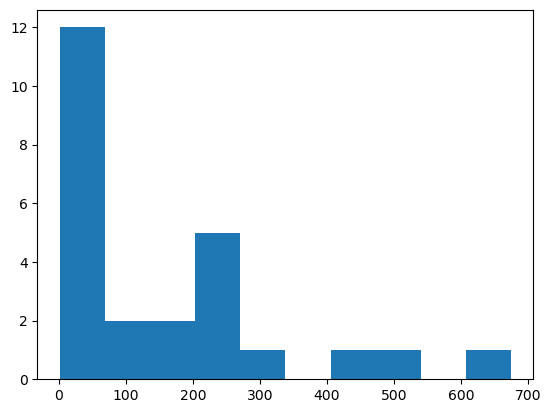

In [147]:
#filter clusters to only those with at least 5 domains
filtered_clusters = [cluster for cluster in domain_clusters if len(cluster) >= 4]
print(f"{len(filtered_clusters)} clusters have at least 4 domains")
#show histogram of number of sequences per domain
from matplotlib import pyplot as plt

plt.hist( [len(c) for c in domain_clusters] )


In [148]:
#create a fasta for each cluster
import os

def clusters2fastas(clusters,fasta_file, fasta_file_3di , output_dir='domain_clusters_fasta'):
	"""
	Create a FASTA file for each cluster of domains.
	
	Parameters:
	- clusters: List of clusters, each cluster is a set of domain IDs
	- fasta_file: Path to FASTA file with full-length domain sequences
	- fasta_file_3di: Path to FASTA file with 3di domain sequences
	- output_dir: Directory to save cluster FASTA files
	"""
	from Bio import SeqIO
	from Bio.SeqRecord import SeqRecord
	import os
	
	# Load sequences
	sequences = {rec.id: rec.seq for rec in SeqIO.parse(fasta_file, 'fasta')}
	sequences_3di = {rec.id: rec.seq for rec in SeqIO.parse(fasta_file_3di, 'fasta')}
	print(f"Loaded {len(sequences)} sequences from {fasta_file}")
	print(f"Loaded {len(sequences_3di)} sequences from {fasta_file_3di}")
	# Create output directory
	for i, cluster in enumerate(clusters, 1):
		cluster_seqs = []
		cluster_seqs_3di = []
		for domain_id in cluster:
			if domain_id in sequences:
				record = SeqRecord(
					sequences[domain_id],
					id=domain_id,
					description=f"Cluster {i}"
				)
				cluster_seqs.append(record)
				cluster_seqs_3di.append(
					SeqRecord(
						sequences_3di[domain_id],
						id=domain_id,
						description=f"Cluster {i}"
					)
				)
		print(f"Cluster {i} has {len(cluster_seqs)} sequences")
		# Write cluster FASTA
		os.makedirs(output_dir, exist_ok=True)
		#make a folder for each cluster
		os.makedirs(os.path.join(output_dir, f'cluster_{i}'), exist_ok=True)
		
		cluster_fasta_file = os.path.join(os.path.join(output_dir, f'cluster_{i}'), f'cluster_{i}.fasta')
		cluster_fasta_file_3di = os.path.join(os.path.join(output_dir, f'cluster_{i}'), f'cluster_{i}_3di.fasta')
		SeqIO.write(cluster_seqs_3di, cluster_fasta_file_3di, 'fasta')
		SeqIO.write(cluster_seqs, cluster_fasta_file, 'fasta')
		
		print(f"Saved cluster {i} with {len(cluster_seqs)} sequences to {cluster_fasta_file}")

#clear the outputdir folder if anything is in there
import shutil	
output_dir = 'domain_clusters_fasta'
shutil.rmtree( output_dir)
os.makedirs(output_dir, exist_ok=True)
os.makedirs('domain_clusters_fasta', exist_ok=True)
clusters2fastas(filtered_clusters, fasta_file='extracted_domains.fasta', fasta_file_3di='extracted_domains_3di.fasta', output_dir='domain_clusters_fasta')

Loaded 4398 sequences from extracted_domains.fasta
Loaded 4398 sequences from extracted_domains_3di.fasta
Cluster 1 has 305 sequences
Saved cluster 1 with 305 sequences to domain_clusters_fasta/cluster_1/cluster_1.fasta
Cluster 2 has 133 sequences
Saved cluster 2 with 133 sequences to domain_clusters_fasta/cluster_2/cluster_2.fasta
Cluster 3 has 193 sequences
Saved cluster 3 with 193 sequences to domain_clusters_fasta/cluster_3/cluster_3.fasta
Cluster 4 has 674 sequences
Saved cluster 4 with 674 sequences to domain_clusters_fasta/cluster_4/cluster_4.fasta
Cluster 5 has 526 sequences
Saved cluster 5 with 526 sequences to domain_clusters_fasta/cluster_5/cluster_5.fasta
Cluster 6 has 250 sequences
Saved cluster 6 with 250 sequences to domain_clusters_fasta/cluster_6/cluster_6.fasta
Cluster 7 has 424 sequences
Saved cluster 7 with 424 sequences to domain_clusters_fasta/cluster_7/cluster_7.fasta
Cluster 8 has 36 sequences
Saved cluster 8 with 36 sequences to domain_clusters_fasta/cluster_8/

In [149]:
#assign a color to each cluster for visualization
def assign_cluster_colors(clusters):
	"""
	Assign a unique color to each cluster.
	
	Parameters:
	- clusters: List of clusters, each cluster is a set of domain IDs
	
	Returns:
	- Dictionary mapping domain IDs to colors
	"""
	import matplotlib.pyplot as plt
	import numpy as np
	
	num_clusters = len(clusters)
	cmap = plt.get_cmap('tab20')
	colors = [cmap(i % 20) for i in range(num_clusters)]
	
	domain_colors = {}
	for i, cluster in enumerate(clusters):
		color = colors[i]
		for domain_id in cluster:
			domain_colors[domain_id] = color
	
	return domain_colors
domain_colors = assign_cluster_colors(domain_clusters)
print(f"Assigned colors to {len(domain_colors)} domains across {len(domain_clusters)} clusters")

Assigned colors to 4042 domains across 25 clusters


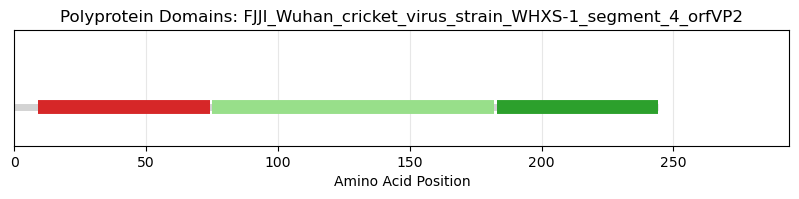

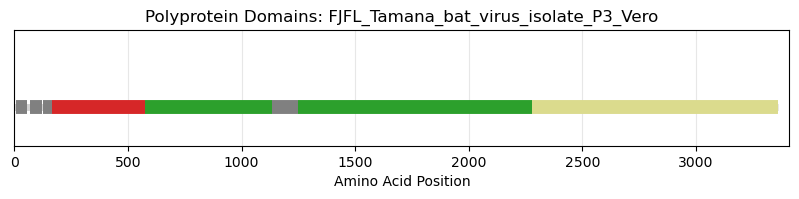

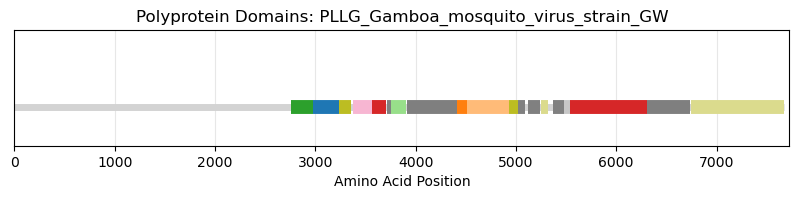

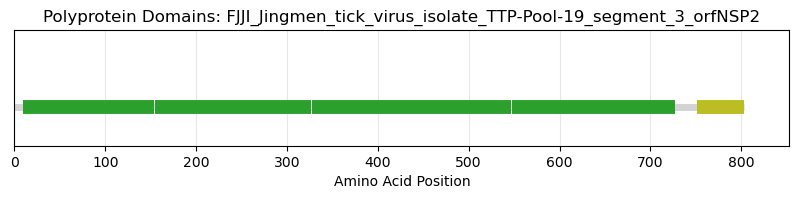

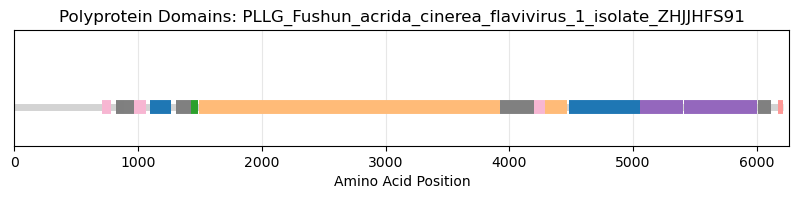

In [154]:
#visualize the clusters in a virus using the colors assigned above
#plot the domains on a linear representation of the polyprotein
def plot_polyprotein_domains(sequence_id, regions_df, domain_colors, output_file=None):
	"""
	Plot domains on a linear representation of the polyprotein.
	
	Parameters:
	- sequence_id: ID of the polyprotein sequence to plot
	- regions_df: DataFrame with domain regions
	- domain_colors: Dictionary mapping domain IDs to colors
	- output_file: If provided, save the plot to this file
	"""
	import matplotlib.pyplot as plt
	
	# Filter regions for the given sequence
	seq_regions = regions_df[regions_df['sequence_id'] == sequence_id]
	
	if seq_regions.empty:
		print(f"No regions found for sequence {sequence_id}")
		return
	
	# Determine polyprotein length
	polyprotein_length = seq_regions['end'].max()
	
	# Create plot
	plt.figure(figsize=(15, 3))
	plt.hlines(1, 0, polyprotein_length, colors='lightgray', linewidth=5)
	
	for _, row in seq_regions.iterrows():
		domain_id = f"{row['sequence_id']}_domain_{row['region_number']}"
		color = domain_colors.get(domain_id, 'gray')
		plt.hlines(1, row['start'], row['end'], colors=color, linewidth=10)
		plt.text((row['start'] + row['end']) / 2, 1.05, f"D{row['region_number']}", 
		         ha='center', va='bottom', fontsize=10, color='black')
	
	plt.title(f'Polyprotein Domains: {sequence_id}', fontsize=14)
	plt.xlabel('Amino Acid Position', fontsize=12)
	plt.yticks([])
	plt.xlim(0, polyprotein_length + 50)
	plt.ylim(0.9, 1.2)
	plt.grid(axis='x', alpha=0.3)
	
	if output_file:
		plt.savefig(output_file, bbox_inches='tight')
		print(f"Saved polyprotein domain plot to {output_file}")
	else:
		plt.show()

#make a small plot with polyprotein domains
#dont label the domains just show the colored boxes
def plot_simple_polyprotein_domains(sequence_id, regions_df, domain_colors, output_file=None):
	"""
	Plot a simple representation of the polyprotein with colored domain boxes.
	
	Parameters:
	- sequence_id: ID of the polyprotein sequence to plot
	- regions_df: DataFrame with domain regions
	- domain_colors: Dictionary mapping domain IDs to colors
	- output_file: If provided, save the plot to this file
	"""
	import matplotlib.pyplot as plt
	
	# Filter regions for the given sequence
	seq_regions = regions_df[regions_df['sequence_id'] == sequence_id]
	
	if seq_regions.empty:
		print(f"No regions found for sequence {sequence_id}")
		return
	
	# Determine polyprotein length
	polyprotein_length = seq_regions['end'].max()
	
	# Create plot
	plt.figure(figsize=(10, 1.5))
	plt.hlines(1, 0, polyprotein_length, colors='lightgray', linewidth=5)
	
	for _, row in seq_regions.iterrows():
		domain_id = f"{row['sequence_id']}_domain_{row['region_number']}"
		color = domain_colors.get(domain_id, 'gray')
		plt.hlines(1, row['start'], row['end'], colors=color, linewidth=10)
	
	plt.title(f'Polyprotein Domains: {sequence_id}', fontsize=12)
	plt.xlabel('Amino Acid Position', fontsize=10)
	plt.yticks([])
	plt.xlim(0, polyprotein_length + 50)
	plt.ylim(0.9, 1.2)
	plt.grid(axis='x', alpha=0.3)
	
	if output_file:
		plt.savefig(output_file, bbox_inches='tight')
		print(f"Saved simple polyprotein domain plot to {output_file}")
	else:
		plt.show()

#plot 5 random viral proteomes

for i in range(5):
	first_seq = random.choice(list(consensus_regions.keys()))
	plot_simple_polyprotein_domains(first_seq, regions_df, domain_colors)

In [ ]:
#create a tree for each domain cluster


In [ ]:
#compile consensus tree from all trees

In [ ]:
#select random leaves 